In [ ]:
import pandas as pd

# Load the combined dataset
file_path = "/content/reddit_posts_cleaned_26Jan-23Feb_v3.csv"
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,Author,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title
0,mamboitalianoo,2025-01-31 21:32:39,1,A couple years ago I had a bout of panic attac...,"['A', 'couple', 'years', 'ago', 'I', 'had', 'a...",Anxiety,Panic attack or vertigo?
1,Midori_sho,2025-01-31 21:31:03,1,School has been kicking my ass lately. My midt...,"['School', 'has', 'been', 'kicking', 'my', 'as...",Anxiety,I think I’m actually stupid as hell
2,No_Entrepreneur_4395,2025-01-31 21:29:09,1,"I've never been diagnosed by a doctor, but I'm...","['I', ""'ve"", 'never', 'been', 'diagnosed', 'by...",Anxiety,Is being medicated better?
3,Successful-Bat-5287,2025-01-31 21:22:31,1,Long time anxiety sufferer here. I’ve done the...,"['Long', 'time', 'anxiety', 'sufferer', 'here'...",Anxiety,My body is anxious but I’m not?
4,ratherdream,2025-01-31 21:07:44,1,I'm so afraid of losing the ones I love and my...,"['I', ""'m"", 'so', 'afraid', 'of', 'losing', 't...",Anxiety,Afraid to loose people


In [ ]:
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
df.isnull().sum()

,0
Author,66
Created_DateTime,0
Score,0
Selftext,62
Tokenized_Selftext,0
Subreddit,0
Title,0


In [ ]:
df.describe()

,Score
count,11803.000000
mean,15.607981
std,130.562577
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5281.000000


In [ ]:
def clean_and_tokenize(text):
    if pd.isna(text):  # Handle NaN values
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Tokenize words
    tokens = word_tokenize(text)

    # Remove punctuation and stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    return " ".join(tokens)  # Return cleaned text as a string

In [ ]:
# Create a new column with tokenized and cleaned text
df["New_Token_Selftext"] = df["Selftext"].apply(clean_and_tokenize)

# Display the updated DataFrame
df.head()

,Author,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title,New_Token_Selftext
0,mamboitalianoo,2025-01-31 21:32:39,1,A couple years ago I had a bout of panic attac...,"['A', 'couple', 'years', 'ago', 'I', 'had', 'a...",Anxiety,Panic attack or vertigo?,couple years ago bout panic attacks related cl...
1,Midori_sho,2025-01-31 21:31:03,1,School has been kicking my ass lately. My midt...,"['School', 'has', 'been', 'kicking', 'my', 'as...",Anxiety,I think I’m actually stupid as hell,school kicking ass lately midterms kicked ass ...
2,No_Entrepreneur_4395,2025-01-31 21:29:09,1,"I've never been diagnosed by a doctor, but I'm...","['I', ""'ve"", 'never', 'been', 'diagnosed', 'by...",Anxiety,Is being medicated better?,never diagnosed doctor pretty sure adhd anxiet...
3,Successful-Bat-5287,2025-01-31 21:22:31,1,Long time anxiety sufferer here. I’ve done the...,"['Long', 'time', 'anxiety', 'sufferer', 'here'...",Anxiety,My body is anxious but I’m not?,long time anxiety sufferer done therapies mg e...
4,ratherdream,2025-01-31 21:07:44,1,I'm so afraid of losing the ones I love and my...,"['I', ""'m"", 'so', 'afraid', 'of', 'losing', 't...",Anxiety,Afraid to loose people,afraid losing ones love insecurities make bett...


In [ ]:
df[df.isnull().any(axis=1)]

,Author,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title,New_Token_Selftext
133,China_carp,2025-01-31 03:55:56,1,NaN,[],Anxiety,Exercise makes me happy how do you guys think,
143,thisisausernameAAA,2025-01-31 02:51:02,1,NaN,[],Anxiety,i’m so anxious right i’m so anxious right now ...,
169,NaN,2025-01-31 00:24:18,1,"Male in my early 20s, writing this for my own ...","['Male', 'in', 'my', 'early', '20s', ',', 'wri...",Anxiety,"It’s too late, I have to move on",male early writing therapy always wanted date ...
223,NaN,2025-01-30 19:04:20,1,"I've been experiencing horrible, crippling GI ...","['I', ""'ve"", 'been', 'experiencing', 'horrible...",Anxiety,Could this be caused by anxiety?,experiencing horrible crippling gi symptoms ha...
270,RopeSmall1199,2025-01-30 14:00:31,2,NaN,[],Anxiety,How are you guys able to work when you have ba...,
...,...,...,...,...,...,...,...,...
9814,NaN,2025-02-18 15:28:34,3,"Looking to treat long term chronic, severe anx...","['Looking', 'to', 'treat', 'long', 'term', 'ch...",Anxiety,About to undergo licensed psilocybin assisted ...,looking treat long term chronic severe anxiety...
10062,NaN,2025-02-22 21:53:35,1,This pain sucks,"['This', 'pain', 'sucks']",depression,This would suck,pain sucks
10278,NaN,2025-02-21 20:28:50,2,Has anyone gained weight and needed to increas...,"['Has', 'anyone', 'gained', 'weight', 'and', '...",depression,Need to increase dose after gain?,anyone gained weight needed increase dose medi...
10306,NaN,2025-02-21 17:35:05,3,"i'm 18, i got kicked out of school when I was ...","['i', ""'m"", '18', ',', 'i', 'got', 'kicked', '...",depression,I hate living like this,got kicked school breakdown never graduated li...


In [ ]:
df[df['Selftext'].isnull()]

,Author,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title,New_Token_Selftext
133,China_carp,2025-01-31 03:55:56,1,NaN,[],Anxiety,Exercise makes me happy how do you guys think,
143,thisisausernameAAA,2025-01-31 02:51:02,1,NaN,[],Anxiety,i’m so anxious right i’m so anxious right now ...,
270,RopeSmall1199,2025-01-30 14:00:31,2,NaN,[],Anxiety,How are you guys able to work when you have ba...,
334,ledybug_23,2025-01-30 03:31:11,18,NaN,[],Anxiety,Benzos were the only thing that worked for my ...,
381,LittleMuffin444,2025-01-29 23:59:36,6,NaN,[],Anxiety,Does anyone else deal with a high heart rate e...,
...,...,...,...,...,...,...,...,...
9152,Practical_Mood9097,2025-02-22 03:43:54,1,NaN,[],Anxiety,it's 3:42 am I'm trying to fall asleep but eve...,
9281,RopeSmall1199,2025-02-21 13:24:16,6,NaN,[],Anxiety,Anyone waking up in the morning and immediatel...,
9441,GDM0323,2025-02-20 15:25:56,5,NaN,[],Anxiety,"Health anxiery, I got told I could potentially...",
9550,Fit-Professional8128,2025-02-19 23:06:56,26,NaN,[],Anxiety,Does anybody get annoying random racing though...,


In [ ]:
df.dropna(subset=['Selftext'], inplace=True)

In [ ]:
df[df.isnull().any(axis=1)] #removed rows containing null values in selftext

,Author,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title,New_Token_Selftext
169,NaN,2025-01-31 00:24:18,1,"Male in my early 20s, writing this for my own ...","['Male', 'in', 'my', 'early', '20s', ',', 'wri...",Anxiety,"It’s too late, I have to move on",male early writing therapy always wanted date ...
223,NaN,2025-01-30 19:04:20,1,"I've been experiencing horrible, crippling GI ...","['I', ""'ve"", 'been', 'experiencing', 'horrible...",Anxiety,Could this be caused by anxiety?,experiencing horrible crippling gi symptoms ha...
329,NaN,2025-01-30 04:37:40,22,"I suffer with severe social anxiety, and as a ...","['I', 'suffer', 'with', 'severe', 'social', 'a...",Anxiety,Is it acceptable to wear a full face mask beca...,suffer severe social anxiety result like wear ...
801,NaN,2025-01-27 20:17:13,2,Why do I focus more on my heart rate when I ge...,"['Why', 'do', 'I', 'focus', 'more', 'on', 'my'...",Anxiety,Heart rate,focus heart rate get go bathroom walk anywhere...
875,NaN,2025-01-27 12:13:30,1,Quitting weed\n\nI guess this is more of a ven...,"['Quitting', 'weed', 'I', 'guess', 'this', 'is...",Anxiety,Weed/Anxiety/life in general,quitting weed guess venting post advice anythi...
...,...,...,...,...,...,...,...,...
9814,NaN,2025-02-18 15:28:34,3,"Looking to treat long term chronic, severe anx...","['Looking', 'to', 'treat', 'long', 'term', 'ch...",Anxiety,About to undergo licensed psilocybin assisted ...,looking treat long term chronic severe anxiety...
10062,NaN,2025-02-22 21:53:35,1,This pain sucks,"['This', 'pain', 'sucks']",depression,This would suck,pain sucks
10278,NaN,2025-02-21 20:28:50,2,Has anyone gained weight and needed to increas...,"['Has', 'anyone', 'gained', 'weight', 'and', '...",depression,Need to increase dose after gain?,anyone gained weight needed increase dose medi...
10306,NaN,2025-02-21 17:35:05,3,"i'm 18, i got kicked out of school when I was ...","['i', ""'m"", '18', ',', 'i', 'got', 'kicked', '...",depression,I hate living like this,got kicked school breakdown never graduated li...


In [ ]:
df.isnull().sum()

,0
Author,65
Created_DateTime,0
Score,0
Selftext,0
Tokenized_Selftext,0
Subreddit,0
Title,0
New_Token_Selftext,0


In [ ]:
df['Author'] = df['Author'].fillna('Anonymous')

In [ ]:
df.isnull().sum()

,0
Author,0
Created_DateTime,0
Score,0
Selftext,0
Tokenized_Selftext,0
Subreddit,0
Title,0
New_Token_Selftext,0


In [ ]:
# Save the updated dataset
cleaned_file_path = "/content/reddit_posts_cleaned_26Jan-23Feb_v4.csv"
df.to_csv(cleaned_file_path, index=False)

print(f"Cleaned dataset saved at: {cleaned_file_path}")

Cleaned dataset saved at: /content/reddit_posts_cleaned_26Jan-23Feb_v4.csv


## Lemmatization & Stemmping

In [ ]:
# Install necessary libraries in Google Colab (if not installed)
!pip install -q spacy nltk pandas
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import spacy
import nltk
from nltk.stem import PorterStemmer

In [ ]:
# Load the English model for spaCy (for lemmatization)
nlp = spacy.load("en_core_web_sm")

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

In [ ]:
# Load the dataset
file_path = "/content/reddit_posts_cleaned_26Jan-23Feb_v4_new_self_token.csv"  # Update if needed
df = pd.read_csv(file_path)

In [ ]:
# Define function for lemmatization using spaCy
def lemmatize_text(text):
    if isinstance(text, str):
        doc = nlp(text)
        return " ".join([token.lemma_ for token in doc])
    return text

In [ ]:
# Apply lemmatization and stemming to 'New Token Selftext'
df['Lemmatized_Text'] = df['New_Token_Selftext'].apply(lemmatize_text)

# Merge lemmatized and stemmed text into a single column
df['Merged_Lemma_Token'] = df['Lemmatized_Text']

# Save the updated dataset as a CSV file
output_file = "/content/reddit_posts_processed.csv"
df.to_csv(output_file, index=False)

# Display sample results
df[['New_Token_Selftext', 'Lemmatized_Text', 'Merged_Lemma_Token']].head()

,New_Token_Selftext,Lemmatized_Text,Merged_Lemma_Token
0,couple years ago bout panic attacks related cl...,couple year ago bout panic attack relate claus...,couple year ago bout panic attack relate claus...
1,school kicking ass lately midterms kicked ass ...,school kicking ass lately midterm kick ass get...,school kicking ass lately midterm kick ass get...
2,never diagnosed doctor pretty sure adhd anxiet...,never diagnose doctor pretty sure adhd anxiety...,never diagnose doctor pretty sure adhd anxiety...
3,long time anxiety sufferer done therapies mg e...,long time anxiety sufferer do therapy mg effex...,long time anxiety sufferer do therapy mg effex...
4,afraid losing ones love insecurities make bett...,afraid lose one love insecurity make well scar...,afraid lose one love insecurity make well scar...


In [ ]:
df.head()

,Author,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title,New_Token_Selftext,Lemmatized_Text,Merged_Lemma_Token
0,mamboitalianoo,2025-01-31 21:32:39,1,A couple years ago I had a bout of panic attac...,"['A', 'couple', 'years', 'ago', 'I', 'had', 'a...",Anxiety,Panic attack or vertigo?,couple years ago bout panic attacks related cl...,couple year ago bout panic attack relate claus...,couple year ago bout panic attack relate claus...
1,Midori_sho,2025-01-31 21:31:03,1,School has been kicking my ass lately. My midt...,"['School', 'has', 'been', 'kicking', 'my', 'as...",Anxiety,I think I’m actually stupid as hell,school kicking ass lately midterms kicked ass ...,school kicking ass lately midterm kick ass get...,school kicking ass lately midterm kick ass get...
2,No_Entrepreneur_4395,2025-01-31 21:29:09,1,"I've never been diagnosed by a doctor, but I'm...","['I', ""'ve"", 'never', 'been', 'diagnosed', 'by...",Anxiety,Is being medicated better?,never diagnosed doctor pretty sure adhd anxiet...,never diagnose doctor pretty sure adhd anxiety...,never diagnose doctor pretty sure adhd anxiety...
3,Successful-Bat-5287,2025-01-31 21:22:31,1,Long time anxiety sufferer here. I’ve done the...,"['Long', 'time', 'anxiety', 'sufferer', 'here'...",Anxiety,My body is anxious but I’m not?,long time anxiety sufferer done therapies mg e...,long time anxiety sufferer do therapy mg effex...,long time anxiety sufferer do therapy mg effex...
4,ratherdream,2025-01-31 21:07:44,1,I'm so afraid of losing the ones I love and my...,"['I', ""'m"", 'so', 'afraid', 'of', 'losing', 't...",Anxiety,Afraid to loose people,afraid losing ones love insecurities make bett...,afraid lose one love insecurity make well scar...,afraid lose one love insecurity make well scar...


## Wordcloud

In [ ]:
import matplotlib.pyplot as plt

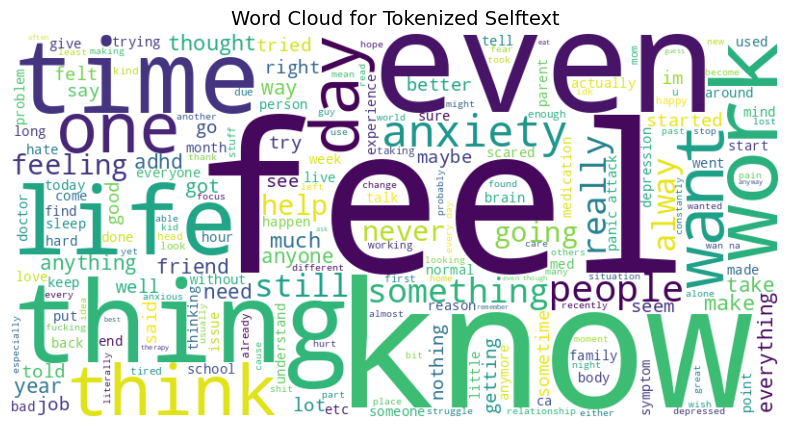

In [ ]:
from wordcloud import WordCloud
if 'New_Token_Selftext':
    # Convert tokenized text column into a single string
    text_data = ' '.join(df['New_Token_Selftext'].dropna().astype(str))

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_data)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")  # Hide axes
    plt.title("Word Cloud for Tokenized Selftext", fontsize=14)
    plt.show()
else:
    print("Column 'Tokenized_Selftext' not found in the dataset.")

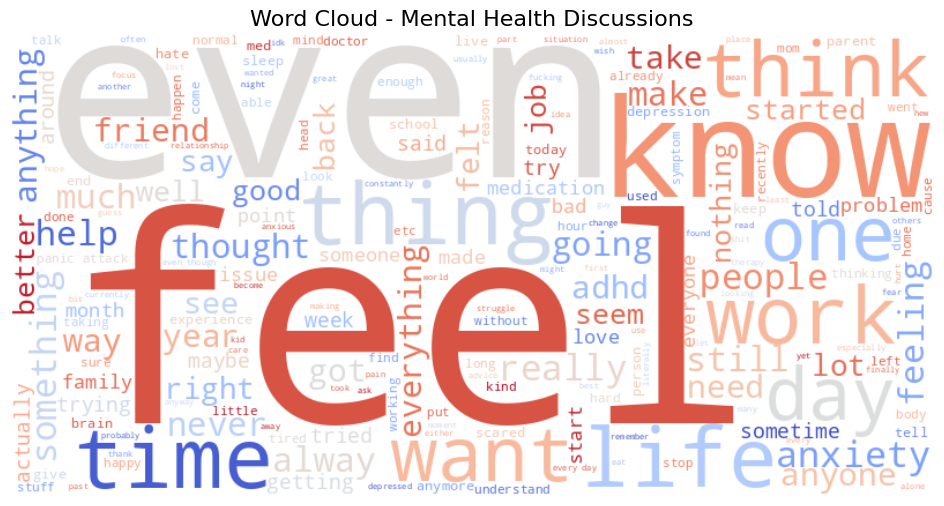

In [ ]:
# Combine all tokenized selftexts into a single text
all_text = " ".join(df["New_Token_Selftext"].dropna())

# Tokenize words
tokens = word_tokenize(all_text)

# Remove stopwords and words shorter than 3 characters
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in tokens if word not in stop_words and len(word) > 2]

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='coolwarm',
    max_words=200
).generate(" ".join(filtered_words))

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Mental Health Discussions", fontsize=16)
plt.show()

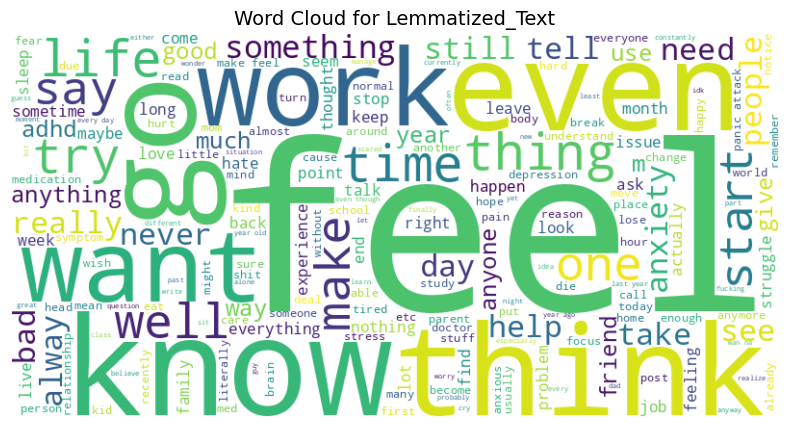

In [ ]:
from wordcloud import WordCloud
if 'Lemmatized_Text':
    # Convert tokenized text column into a single string
    text_data = ' '.join(df['Lemmatized_Text'].dropna().astype(str))

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_data)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")  # Hide axes
    plt.title("Word Cloud for Lemmatized_Text", fontsize=14)
    plt.show()
else:
    print("Column 'Tokenized_Selftext' not found in the dataset.")

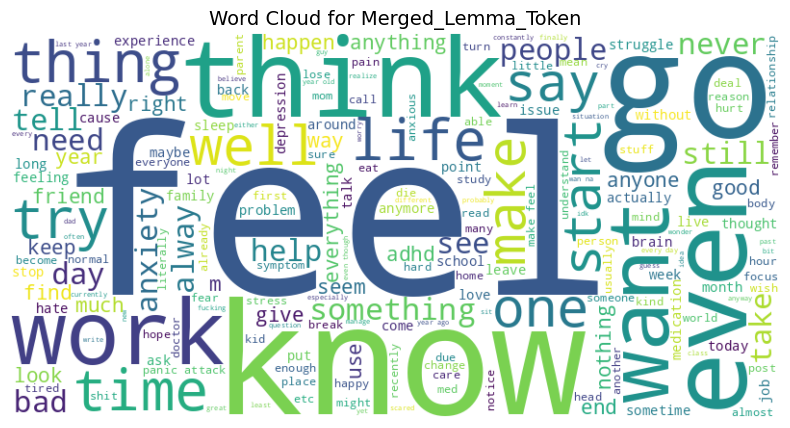

In [ ]:
from wordcloud import WordCloud
if 'Merged_Lemma_Token':
    # Convert tokenized text column into a single string
    text_data = ' '.join(df['Merged_Lemma_Token'].dropna().astype(str))

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_data)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")  # Hide axes
    plt.title("Word Cloud for Merged_Lemma_Token", fontsize=14)
    plt.show()
else:
    print("Column 'Tokenized_Selftext' not found in the dataset.")

## Subreddit Word Cloud

In [ ]:
# Install necessary libraries if not installed
!pip install -q wordcloud matplotlib pandas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# Load the dataset
file_path = "/content/reddit_posts_processed.csv"  # Update if needed
df = pd.read_csv(file_path)

In [ ]:
# Ensure column names are correct
text_column = "Merged_Lemma_Token"  # The column containing the processed text
subreddit_column = "Subreddit"      # The column containing subreddit names

In [ ]:
# Filter data for specific subreddits
subreddits = ["Anxiety", "depression", "ADHD"]

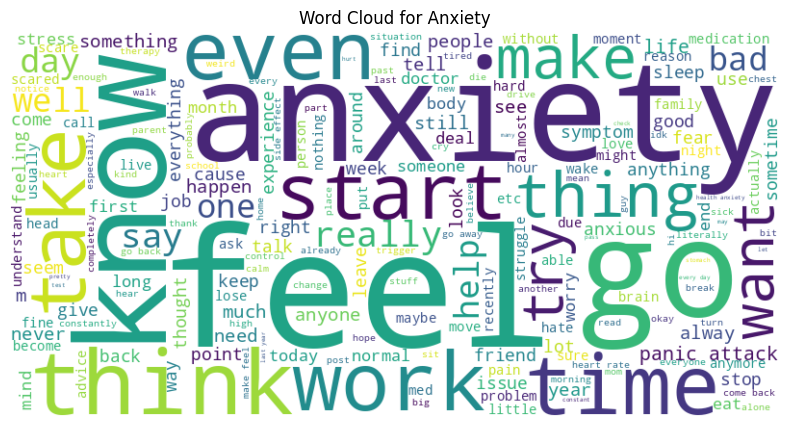

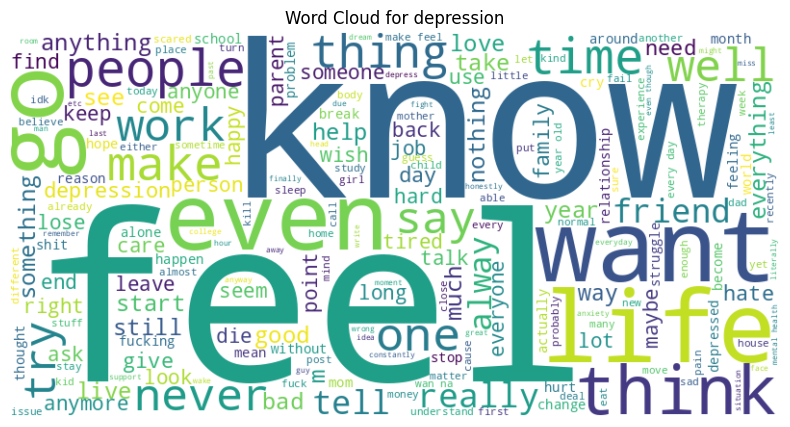

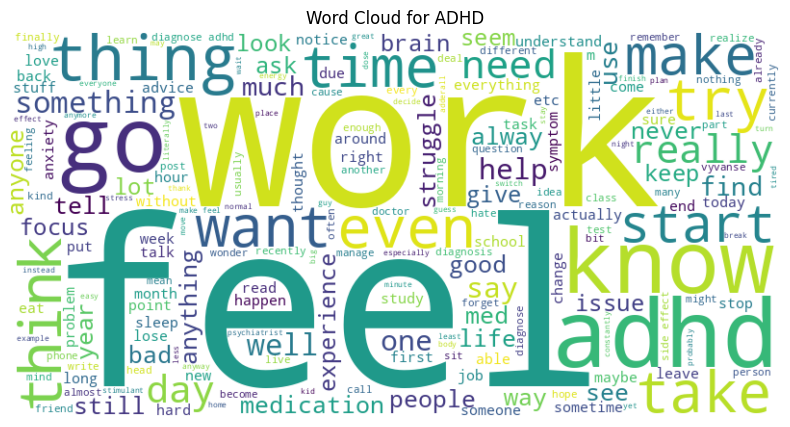

In [ ]:
# Function to generate word cloud
def generate_wordcloud(subreddit, text_data):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

    # Display the wordcloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {subreddit}")
    plt.show()

# Generate and display word clouds for each subreddit
for sub in subreddits:
    sub_data = df[df[subreddit_column] == sub]
    text_data = " ".join(sub_data[text_column].dropna())  # Combine text
    if text_data.strip():  # Ensure there's text to display
        generate_wordcloud(sub, text_data)
    else:
        print(f"No text data available for {sub} subreddit.")

## Medication Wordcloud

In [ ]:
from collections import Counter

In [ ]:
# Comprehensive list of medications (including the ones you specified)
medication_list = {
    "prozac", "fluoxetine", "lexapro", "escitalopram", "zoloft", "sertraline", "paxil", "paroxetine",
    "celexa", "citalopram", "wellbutrin", "bupropion", "effexor", "venlafaxine", "cymbalta", "duloxetine",
    "abilify", "aripiprazole", "risperdal", "risperidone", "lamictal", "lamotrigine", "vyvanse", "lisdexamfetamine",
    "adderall", "amphetamine", "ritalin", "methylphenidate", "concerta", "strattera", "atomoxetine",
    "xanax", "alprazolam", "klonopin", "clonazepam", "ativan", "lorazepam", "valium", "diazepam",
    "seroquel", "quetiapine", "lithium", "buspar", "buspirone", "propranolol", "ssri"
}

# Extract medication mentions from the dataset
medication_counts = Counter()

for text in df["New_Token_Selftext"].dropna():
    tokens = word_tokenize(text.lower())  # Convert to lowercase to match consistently
    filtered_meds = [word for word in tokens if word in medication_list]
    medication_counts.update(filtered_meds)

# Convert to a format suitable for WordCloud
medications_text = " ".join([word for word, freq in medication_counts.items()])

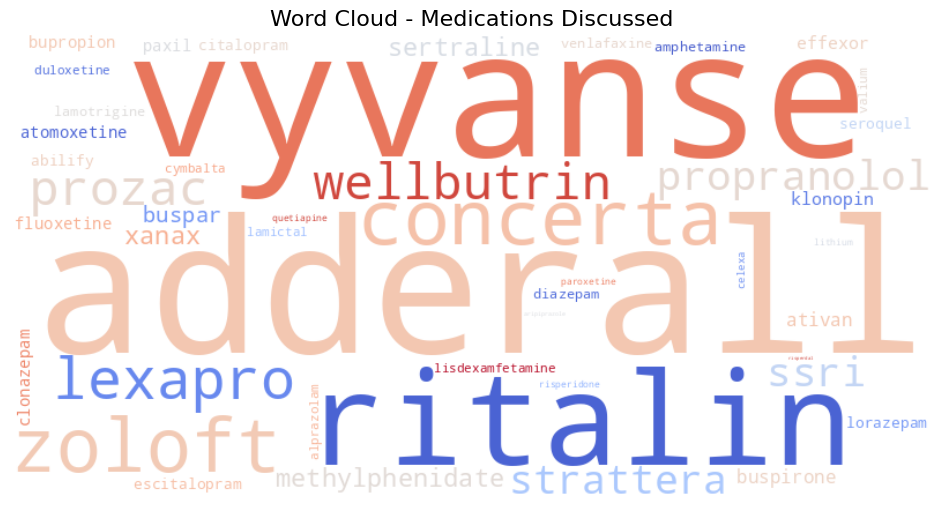

In [ ]:
# Generate the word cloud for medications
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='coolwarm',
    max_words=100,  # Limit to top 100 unique words
    normalize_plurals=True  # Ensures variations like "prozacs" count as "prozac"
).generate_from_frequencies(medication_counts)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Medications Discussed", fontsize=16)
plt.show()

## Time Series Analysis

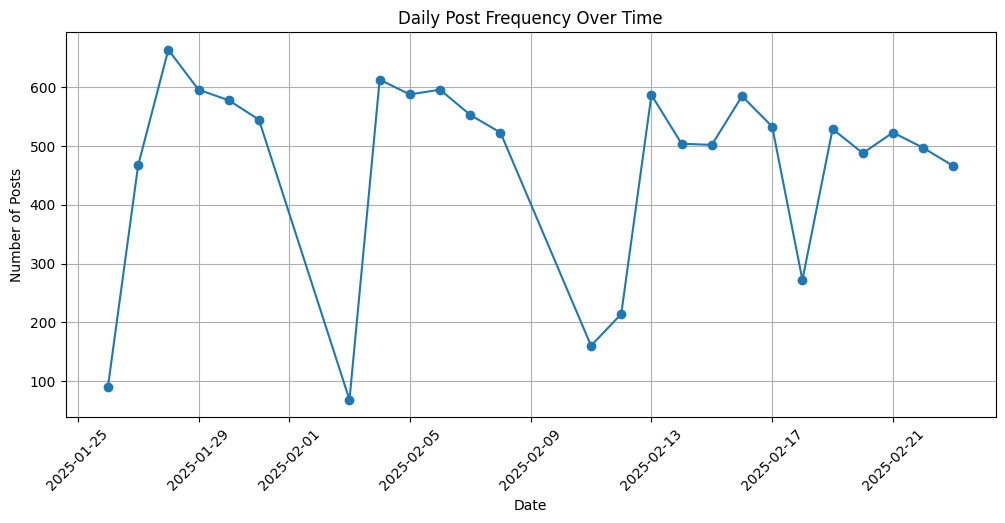

In [ ]:
import matplotlib.pyplot as plt

# Convert 'Created_DateTime' to datetime format
df['Created_DateTime'] = pd.to_datetime(df['Created_DateTime'])

# Extract date for daily analysis
df['Date'] = df['Created_DateTime'].dt.date

# Aggregate posts per day
daily_posts = df.groupby('Date').size()

# Plot daily posting trends
plt.figure(figsize=(12, 5))
plt.plot(daily_posts.index, daily_posts.values, marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title("Daily Post Frequency Over Time")
plt.xticks(rotation=45)
plt.grid(True)

# Show the plot
plt.show()

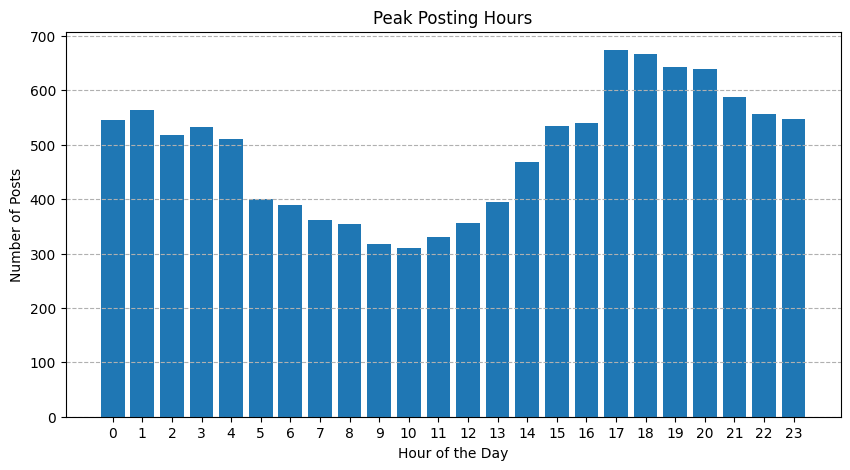

In [ ]:
# Extract hour from timestamp
df['Hour'] = df['Created_DateTime'].dt.hour

# Aggregate posts per hour
hourly_posts = df.groupby('Hour').size()

# Plot posting frequency by hour
plt.figure(figsize=(10, 5))
plt.bar(hourly_posts.index, hourly_posts.values)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Posts")
plt.title("Peak Posting Hours")
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--')

# Show the plot
plt.show()

<ipython-input-42-bb3ae4d185f7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subreddit["Hour"] = df_subreddit["Created_DateTime"].dt.hour


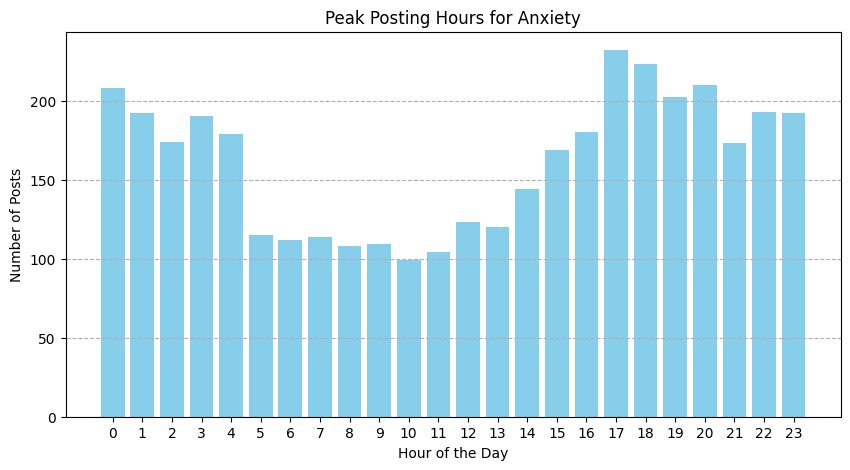

<ipython-input-42-bb3ae4d185f7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subreddit["Hour"] = df_subreddit["Created_DateTime"].dt.hour


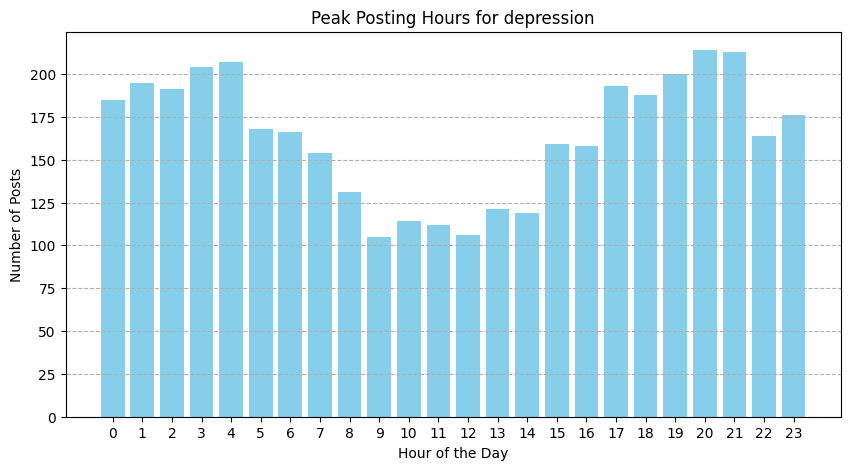

<ipython-input-42-bb3ae4d185f7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subreddit["Hour"] = df_subreddit["Created_DateTime"].dt.hour


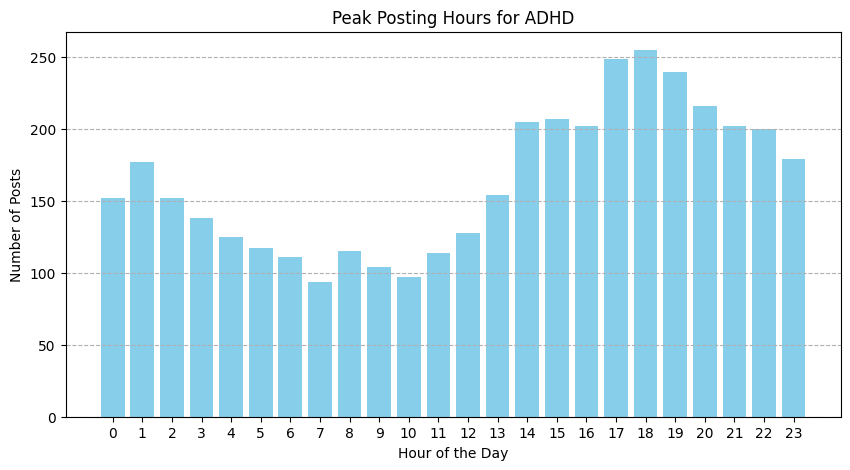

In [ ]:
# Define the subreddits to analyze
subreddits_to_analyze = ["Anxiety", "depression", "ADHD"]

# Create separate plots for each subreddit
for subreddit in subreddits_to_analyze:
    # Filter data for the specific subreddit
    df_subreddit = df[df["Subreddit"] == subreddit]

    # Extract hour from timestamp
    df_subreddit["Hour"] = df_subreddit["Created_DateTime"].dt.hour

    # Aggregate posts per hour
    hourly_posts = df_subreddit.groupby("Hour").size()

    # Plot posting frequency by hour
    plt.figure(figsize=(10, 5))
    plt.bar(hourly_posts.index, hourly_posts.values, color="skyblue")
    plt.xlabel("Hour of the Day")
    plt.ylabel("Number of Posts")
    plt.title(f"Peak Posting Hours for {subreddit}")
    plt.xticks(range(0, 24))
    plt.grid(axis="y", linestyle="--")

    # Show the plot
    plt.show()

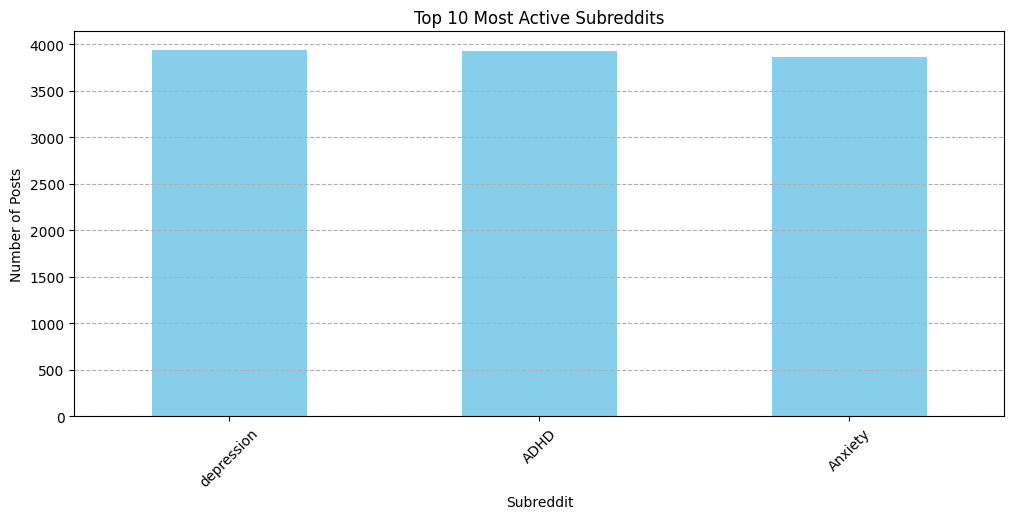

In [ ]:
# Count posts per subreddit
subreddit_counts = df['Subreddit'].value_counts().head(10)  # Top 10 subreddits

# Plot subreddit distribution
plt.figure(figsize=(12, 5))
subreddit_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Subreddit")
plt.ylabel("Number of Posts")
plt.title("Top 10 Most Active Subreddits")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

# Show the plot
plt.show()

In [ ]:
### 5️⃣ **Top 10 Performing Posts (Highest Score)**
top_posts = df[['Title', 'Subreddit', 'Created_DateTime', 'Score', 'Author']].sort_values(by='Score', ascending=False).head(10)
print("\n🔝 **Top 10 Most Engaging Posts**")
display(top_posts)


🔝 **Top 10 Most Engaging Posts**


,Title,Subreddit,Created_DateTime,Score,Author
8314,"RFK Jr., now confirmed, is a threat to our exi...",ADHD,2025-02-13 20:27:35,5264,ZombieDracula
8240,Trump & Kennedy are coming for your meds,ADHD,2025-02-14 13:26:24,4338,rmb185
5449,The #1 thing I’ve learned from being on adhd meds,ADHD,2025-02-06 00:29:52,3404,ThickEfficiency8257
5279,New hack to be always on time. Turn on GPS map...,ADHD,2025-02-06 22:29:08,3335,KJAR14
11080,Anybody been procrastinating for like over 5 y...,ADHD,2025-02-21 08:01:54,2989,Django-lango
2319,"Concern Over Health Secretary's Comment That ""...",ADHD,2025-01-29 20:00:04,2673,jajajajajjajjjja
10808,Tip: The ASL alphabet helps me not interrupt w...,ADHD,2025-02-23 07:00:35,2550,GriffinGotGun
8590,Where are my fellow ADHD (inattentive) type ba...,ADHD,2025-02-12 06:45:25,2501,therapyreplacement_
8374,How are people not completely falling apart al...,ADHD,2025-02-13 13:49:05,2422,kaleidescopestar
2444,I learned of a new cabinet in my kitchen. I do...,ADHD,2025-01-29 01:54:15,2391,LinkDude80


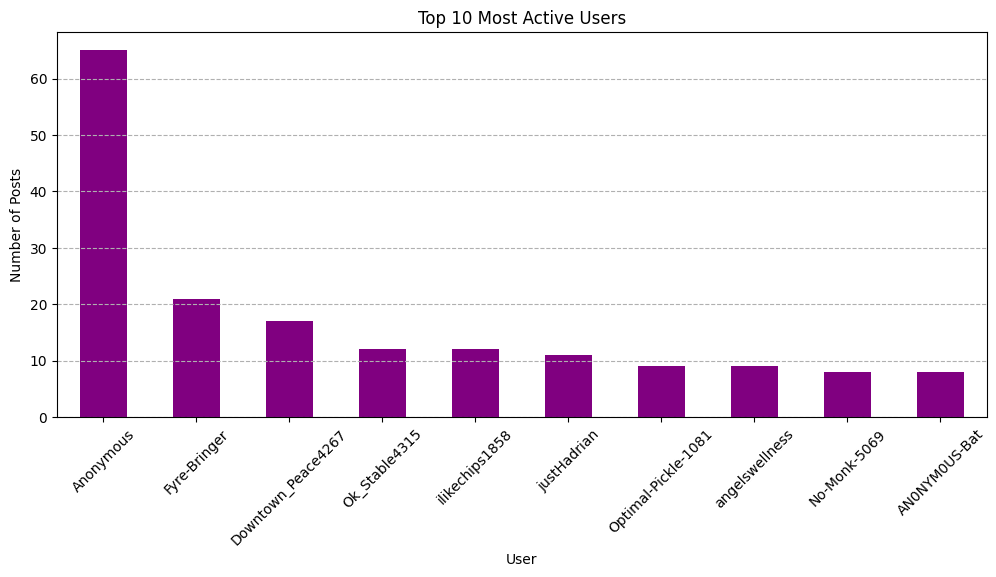

In [ ]:
# Get the top 10 most active users
top_users = df['Author'].value_counts().head(10)

# Plot most active users
plt.figure(figsize=(12, 5))
top_users.plot(kind='bar', color='purple')
plt.xlabel("User")
plt.ylabel("Number of Posts")
plt.title("Top 10 Most Active Users")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

# Show the plot
plt.show()

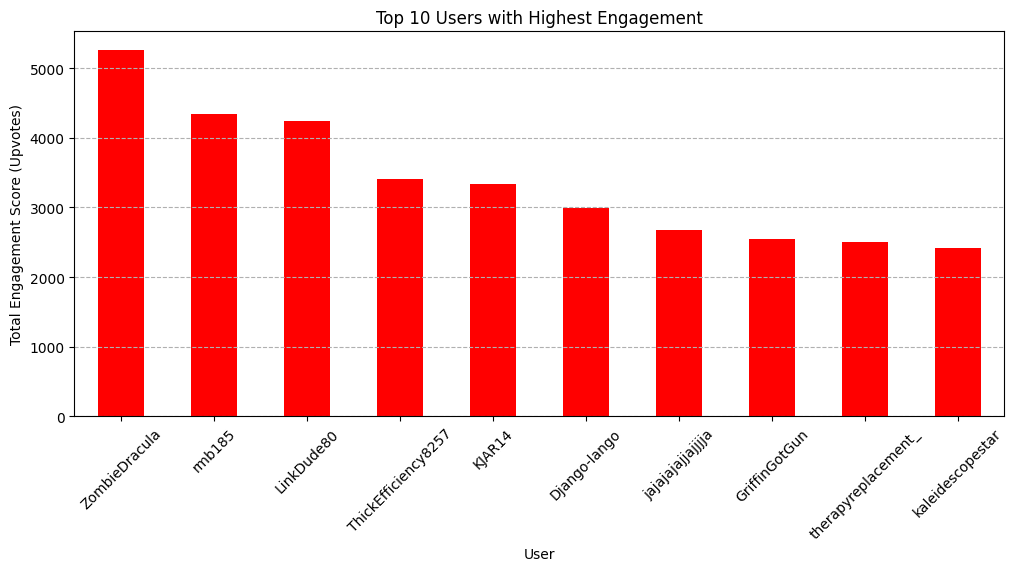

In [ ]:
# Calculate total engagement per user
user_engagement = df.groupby('Author')['Score'].sum().sort_values(ascending=False).head(10)

# Plot most engaged users
plt.figure(figsize=(12, 5))
user_engagement.plot(kind='bar', color='red')
plt.xlabel("User")
plt.ylabel("Total Engagement Score (Upvotes)")
plt.title("Top 10 Users with Highest Engagement")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

# Show the plot
plt.show()